In [3]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing(as_frame=True)
df=data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


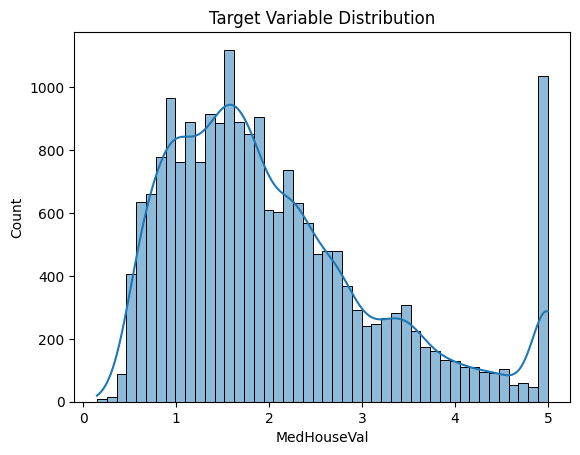

In [6]:
plt.Figure(figsize=(6,10))
sns.histplot(data=df["MedHouseVal"],kde=True)
plt.title("Target Variable Distribution")
plt.show()

In [7]:
!pip install ydata-profiling

ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.17.0 Requires-Python >=3.7,<3.14; 4.18.0 Requires-Python >=3.10,<3.14; 4.18.1 Requires-Python >=3.10,<3.14; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Python >=3.7,<3.12; 4.6.0 Requires-Python >=3.7,<3

In [8]:
from ydata_profiling import profile_report

c:\Users\moizikha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
X=df.drop("MedHouseVal",axis=1)
y=df["MedHouseVal"]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [11]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [12]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)
y_pred_lr=linear_model.predict(X_test)
mse_lr= mean_squared_error(y_test,y_pred_lr)
mae_lr=mean_absolute_error(y_test,y_pred_lr)
rme=np.sqrt(mse_lr)
r2_lr=r2_score(y_test,y_pred_lr)

In [13]:
print("Linear Regression Performance")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rme)
print("R2 Score:", r2_lr)

Linear Regression Performance
MAE: 0.5332001304956558
MSE: 0.555891598695244
RMSE: 0.7455813830127761
R2 Score: 0.5757877060324511


In [14]:
lasso=Lasso(alpha=0.01)
lasso.fit(X_train,y_train)
y_pred_las=lasso.predict(X_test)

In [15]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
y_pred_rid=ridge.predict(X_test)

In [16]:
dt_model=DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train,y_train)
y_pred_dt=dt_model.predict(X_test)

In [17]:
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

In [18]:
models={
    "Linear":y_pred_lr,
    "Lasso":y_pred_las,
    "Ridge":y_pred_rid,
    "d_Tree":y_pred_dt,
    "r_forest":y_pred_rf
}

for name,score in models.items():
    print(name , "R2" , r2_score(y_test,score))

Linear R2 0.5757877060324511
Lasso R2 0.5845196673976369
Ridge R2 0.5758549611440127
d_Tree R2 0.622075845135081
r_forest R2 0.8051230593157366


In [19]:
new_house = [[8.3252,	41.0,	6.984127,	1.023810,	322.0,	2.555556,	37.88,	-122.23]]

In [20]:
ans=rf_model.predict(new_house)
print("House prediction :" ,ans[0])

House prediction : 4.265793


c:\Users\moizikha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [21]:
# Sklearn pipeline
# model saving
# Streamlit application

In [22]:
from sklearn.pipeline import make_pipeline
import joblib

In [23]:
data=fetch_california_housing(as_frame=True)
df=data.frame

In [24]:
X=df.drop("MedHouseVal",axis=1)
y=df["MedHouseVal"]

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
rf_pipeline=make_pipeline(
    RandomForestRegressor(n_estimators=100,random_state=42)
)
rf_pipeline.fit(X_train,y_train)

,steps,"[('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [28]:
y_pred_pipe=rf_pipeline.predict(X_test)
print(
    "Random forest pipeline score :",
    r2_score(y_test,y_pred_pipe)
)

Random forest pipeline score : 0.8051230593157366
